In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.distances import sbd_distance
from sktime.dists_kernels import NCCKernel

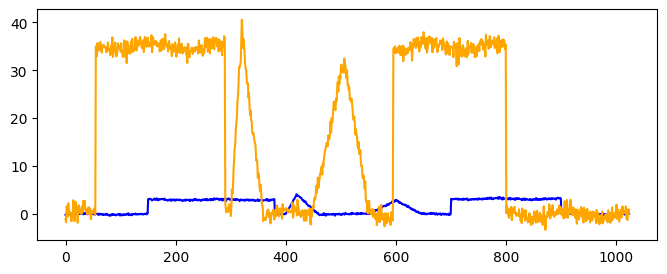

In [2]:
# Define the time series
t = np.arange(1024)
y1 = np.sin(t / 20) + np.random.normal(0, 1, 1024)
y2 = np.sin(t / 20) + np.random.normal(0, 1, 1024)

y1[150:380] += 30.0
y2[55:290] += 35.0

y1[400:420] += 40 * np.arange(20) / 20
y1[420:460] += 40 * (1 - np.arange(40) / 40)
y2[300:320] += 38 * np.arange(20) / 20
y2[320:360] += 38 * (1 - np.arange(40) / 40)

y1[550:600] += 30 * np.arange(50) / 50
y1[600:645] += 30 * (1 - np.arange(45) / 45)
y2[445:505] += 32 * np.arange(60) / 60
y2[505:550] += 32 * (1 - np.arange(45) / 45)

y1[700:900] += 32.0
y2[595:800] += 35.0

y1 /= 10.0

plt.figure(figsize=(8, 3))
plt.plot(y1, color='blue')
plt.plot(y2, color='orange')

Text(0.5, 1.0, 'SBD=0.025')

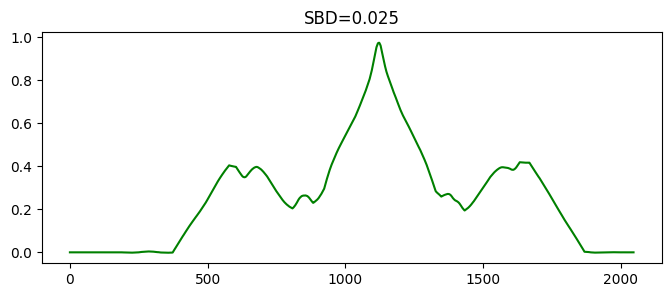

In [3]:
sbd_12 = sbd_distance(y1, y2)
ncc_12 = NCCKernel.ncc_profile(y1, y2)

# Plot the NCC curve and show SBD from sktime
plt.figure(figsize=(8, 3))
plt.plot(ncc_12, color='green')
plt.title(f"SBD={sbd_12:.3f}")

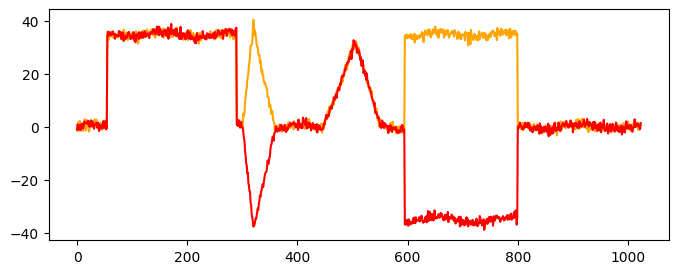

In [4]:
# Set y3 and recalculate sbd
y3 = np.sin(t / 20) + np.random.normal(0, 1, 1024)
y3[55:290] += 35.0

y3[300:320] -= 38 * np.arange(20) / 20
y3[320:360] -= 38 * (1 - np.arange(40) / 40)

y3[445:505] += 32 * np.arange(60) / 60
y3[505:550] += 32 * (1 - np.arange(45) / 45)

y3[595:800] -= 35.0
plt.figure(figsize=(8, 3))
plt.plot(y2, color='orange')
plt.plot(y3, color='red')

Text(0.5, 1.0, 'SBD=0.584')

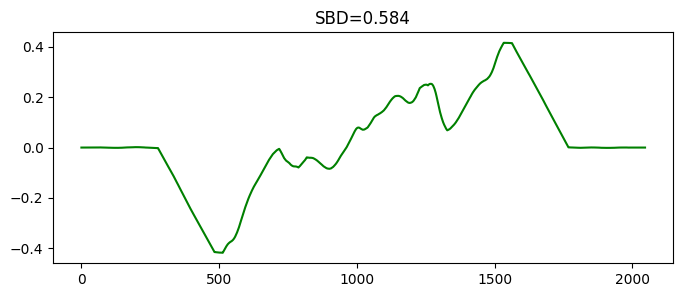

In [5]:
sbd_23 = sbd_distance(y2, y3)
ncc_23 = NCCKernel.ncc_profile(y2, y3)

# Plot the NCC curve and show SBD from sktime
plt.figure(figsize=(8, 3))
plt.plot(ncc_23, color='green')
plt.title(f"SBD={sbd_23:.3f}")